<a href="https://colab.research.google.com/github/ODUNAYOMIDE-YAKUBU/sentiment_chatbot/blob/main/phase2_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sentiment Chatbot

In [1]:
!pip install datasets transformers pandas numpy -q
from datasets import load_dataset
import pandas as pd

### Searching for `NaijaSenti` on Hugging Face

You can search for datasets on the Hugging Face Hub using their website:

1.  **Go to the Hugging Face Datasets page:** [https://huggingface.co/datasets](https://huggingface.co/datasets)
2.  **Use the search bar:** Type `NaijaSenti` (or related terms like 'Nigerian sentiment') into the search bar.
3.  **Explore results:** Review the search results for a dataset that matches your needs and has a valid loading method (i.e., not relying on a deprecated loading script).

Alternatively, you can use the `huggingface_hub` library to search for datasets programmatically:

In [2]:
from huggingface_hub import list_datasets

search_term = "NaijaSenti"
# List datasets from the Hugging Face Hub that might contain the search term
datasets_found = list(list_datasets(search=search_term, full=True))

if datasets_found:
    print(f"Found {len(datasets_found)} datasets matching '{search_term}':")
    for dataset_info in datasets_found:
        print(f"- {dataset_info.id}")
else:
    print(f"No datasets found on Hugging Face Hub matching '{search_term}'. You may need to refine your search term or check the original GitHub repository for other data sources.")


Found 4 datasets matching 'NaijaSenti':
- HausaNLP/NaijaSenti-Twitter
- mteb/NaijaSenti
- mteb/naija_senti
- cike-dev/NaijaSenti_pcm


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Dataset 1: NaijaSenti-Twitter'datast

In [10]:
import pandas as pd
from datasets import load_dataset

# Load the Nigerian Pidgin (pcm) split from an alternative dataset
naijasenti_hf = load_dataset('HausaNLP/NaijaSenti-Twitter','pcm')
print("NaijaSenti-Twitter pcm split loaded successfully from HausaNLP/NaijaSenti-Twitter")

# Convert the 'train' split to a DataFrame
df_naija_hf = pd.DataFrame(naijasenti_hf['train'])
print(df_naija_hf.head())

NaijaSenti-Twitter pcm split loaded successfully from HausaNLP/NaijaSenti-Twitter
                                               tweet  label
0  yeah ‍️the guy wants to trend dat was why e jo...      2
1  this life is so funny sef you will work hard a...      2
2  dis is unfair of urcompany goingtowks nw ive b...      2
3  lil wayne don vex me im actually not excited a...      2
4  dis is unfair of ur company going to wks nw iv...      2


## Data 2: Sentiment 140 of 1.6 Million records
**Context**

This is the sentiment140 dataset. It contains 1,600,000 tweets extracted using the twitter api . The tweets have been annotated (0 = negative, 4 = positive) and they can be used to detect sentiment .

In [11]:
import pandas as pd
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

# After downloading sentiment140.csv from Kaggle to your Colab environment
# Construct the full path to the CSV file with the correct filename

csv_file_path = os.path.join(path, "training.1600000.processed.noemoticon.csv")
df_sent140 = pd.read_csv(csv_file_path, encoding='latin-1', header=None)
# Typical columns: [target, id, date, flag, user, text]
df_sent140 = df_sent140[[0,5]]
df_sent140.columns = ['label','text']

# Map labels (0 negative, 4 positive) to 0/1
df_sent140['label'] = df_sent140['label'].map({0:0, 4:1})
df_sent140 = df_sent140.sample(n=10000, random_state=42).reset_index(drop=True)

Using Colab cache for faster access to the 'sentiment140' dataset.
Path to dataset files: /kaggle/input/sentiment140


In [12]:
!pip install datasets==2.14.7 -q

df_empathy = pd.read_parquet(
    "https://huggingface.co/datasets/Estwld/empathetic_dialogues_llm/resolve/main/data/train-00000-of-00001.parquet"
)
df_empathy.to_csv("empathetic_dialogues.csv", index=False)
print(f"Empathy dataset: {len(df_empathy)} rows")
print("Columns:", df_empathy.columns.tolist())

Empathy dataset: 19533 rows
Columns: ['conv_id', 'situation', 'emotion', 'conversations']


In [13]:
print("=== NaijaSenti_Twitter ===")
print(df_naija_hf.shape, df_naija_hf.columns.tolist())

print("\n=== Sentiment140 ===")
print(f"The size is {df_sent140.shape}, the list of the columns are {df_sent140.columns.tolist()}")

print("\n=== Daily Dialog ===")
print(df_empathy.shape, df_empathy.columns.to_list()) # to check the empathy dataset shape fin rows and columns
print("All datasets loaded successfully!")

=== NaijaSenti_Twitter ===
(5121, 2) ['tweet', 'label']

=== Sentiment140 ===
The size is (10000, 2), the list of the columns are ['label', 'text']

=== Daily Dialog ===
(19533, 4) ['conv_id', 'situation', 'emotion', 'conversations']
All datasets loaded successfully!


In [14]:
# NaijaSenti label mapping: 0=negative, 1=neutral, 2=positive
df_naija = df_naija_hf[['tweet', 'label']].copy() # copy the dataset
df_naija.columns = ['text', 'label'] # set as columns
df_naija['sentiment'] = df_naija['label'].map({0: 'negative', 1: 'neutral', 2: 'positive'}) # standardized the records
df_naija = df_naija[['text', 'sentiment']]

# df_naija = df_naija.sample(n=10000, random_state=42).reset_index(drop=True)
print("NaijaSenti label distribution:")
print(df_naija['sentiment'].value_counts())
print(df_naija.head())

NaijaSenti label distribution:
sentiment
positive    3241
negative    1808
neutral       72
Name: count, dtype: int64
                                                text sentiment
0  yeah ‍️the guy wants to trend dat was why e jo...  positive
1  this life is so funny sef you will work hard a...  positive
2  dis is unfair of urcompany goingtowks nw ive b...  positive
3  lil wayne don vex me im actually not excited a...  positive
4  dis is unfair of ur company going to wks nw iv...  positive


In [15]:
# Sentiment140 has no neutral — add sentiment column
df_sent140['sentiment'] = df_sent140['label'].map({0: 'negative', 1: 'positive'}) #
df_sent140 = df_sent140[['text', 'sentiment']]

print("Sentiment140 label distribution:")
print(df_sent140['sentiment'].value_counts())
print(df_sent140.head())

Sentiment140 label distribution:
sentiment
negative    5004
positive    4996
Name: count, dtype: int64
                                                text sentiment
0             @chrishasboobs AHHH I HOPE YOUR OK!!!   negative
1  @misstoriblack cool , i have no tweet apps  fo...  negative
2  @TiannaChaos i know  just family drama. its la...  negative
3  School email won't open  and I have geography ...  negative
4                             upper airways problem   negative


In [16]:
# ____________________Merge the two datasets together______________

import pandas as pd

df_combined = pd.concat([df_naija, df_sent140], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)
df_combined.dropna(inplace=True)

print(f"Total combined samples: {len(df_combined)}")
print("\nOverall sentiment distribution:")
print(df_combined['sentiment'].value_counts())
print(df_combined.head(10))

Total combined samples: 15121

Overall sentiment distribution:
sentiment
positive    8237
negative    6812
neutral       72
Name: count, dtype: int64
                                                text sentiment
0  @hannahschmitzer Great great!  haha, can't com...  positive
1  just finished watching series 1 of Mad Men on ...  positive
2  all these people saying this is not the eid de...   neutral
3  the difference between and half dozen na how y...  positive
4   No Longo again today. Better safe than sorry,...  negative
5  @rhettmiller wait, whats this bowery hotel eve...  negative
6  Follow @RetireWithCarla - the 1% ethical group...  positive
7  abeg love o if you see d love this life na jus...  negative
8  bro na so mesef buy am yesterday e pain me but...  positive
9  the woman wey dey supply us moi moi no dey add...  positive


The result show class imbalance which can be dangerous to the our model development if abandon from the neutral class

In [17]:
# Pull neutral samples from val and test splits of NaijaSenti
df_naija_val = pd.DataFrame(naijasenti_hf['validation'])
df_naija_test = pd.DataFrame(naijasenti_hf['test'])

df_naija_extra = pd.concat([df_naija_val, df_naija_test], ignore_index=True)
df_naija_extra.columns = ['text', 'label'] if 'tweet' not in df_naija_extra.columns else df_naija_extra.columns
df_naija_extra = df_naija_extra.rename(columns={'tweet': 'text'})
df_naija_extra['sentiment'] = df_naija_extra['label'].map({0: 'negative', 1: 'neutral', 2: 'positive'})
df_naija_extra = df_naija_extra[['text', 'sentiment']]

# Extract only neutral samples
neutral_extra = df_naija_extra[df_naija_extra['sentiment'] == 'neutral']
print(f"Extra neutral samples found: {len(neutral_extra)}")

Extra neutral samples found: 452


In [18]:
# Create additional neutral samples from common neutral phrases
neutral_synthetic = pd.DataFrame({
    'text': [
        "the weather is okay today",
        "i went to the market this afternoon",
        "the meeting was scheduled for monday",
        "i read the document you sent",
        "she walked to the bus stop",
        "the price of the item is listed online",
        "i will check and get back to you",
        "the package arrived this morning",
        "he said he would come later",
        "i saw the message you sent yesterday",
        "the office opens at 8am",
        "i am on my way now",
        "the food was just okay nothing special",
        "i submitted the form already",
        "we dey go the place later",
        "i no know wetin dey happen",
        "e be like say dem don close",
        "i just dey here dey wait",
        "the thing just dey like that",
        "i go check am when i reach",
        "dem say make we come tomorrow",
        "i never see am since morning",
        "e no bad e no good",
        "i just dey manage am",
        "nothing do am yet"
    ],
    'sentiment': ['neutral'] * 25
})
print(f"Synthetic neutral samples: {len(neutral_synthetic)}")

Synthetic neutral samples: 25


In [19]:
# Combine all neutral sources
all_neutral = pd.concat([
    df_combined[df_combined['sentiment'] == 'neutral'],
    neutral_extra,
    neutral_synthetic
], ignore_index=True)

print(f"Total neutral samples now: {len(all_neutral)}")

# Rebuild combined dataset
df_pos = df_combined[df_combined['sentiment'] == 'positive']
df_neg = df_combined[df_combined['sentiment'] == 'negative']

# Balance: cap positive and negative at 3000 each, neutral at whatever we have (min 500 target)
df_pos_sample = df_pos.sample(n=3000, random_state=42)
df_neg_sample = df_neg.sample(n=3000, random_state=42)

# Get unique neutral samples first
unique_neutral_df = all_neutral.drop_duplicates()

# Determine the number to sample from the unique neutral samples
# Cap at 2000, but don't try to sample more than available unique samples
n_to_sample_neutral = min(len(unique_neutral_df), 2000)

# Sample from the unique neutral samples
df_neu_sample = unique_neutral_df.sample(n=n_to_sample_neutral, random_state=42)

df_balanced = pd.concat([df_pos_sample, df_neg_sample, df_neu_sample], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
df_balanced.dropna(inplace=True)

print(f"\nFinal balanced dataset: {len(df_balanced)} samples")
print(df_balanced['sentiment'].value_counts())

Total neutral samples now: 549

Final balanced dataset: 6545 samples
sentiment
negative    3000
positive    3000
neutral      545
Name: count, dtype: int64


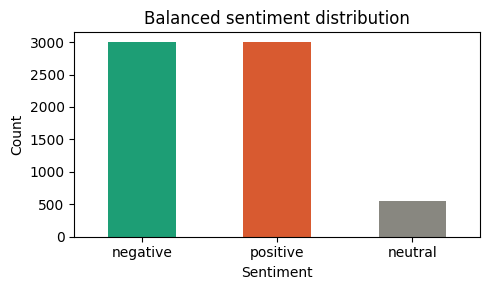

sentiment
negative    3000
positive    3000
neutral      545
Name: count, dtype: int64


In [20]:
import matplotlib.pyplot as plt

counts = df_balanced['sentiment'].value_counts()
colors = ['#1D9E75', '#D85A30', '#888780']
plt.figure(figsize=(5, 3))
counts.plot(kind='bar', color=colors, edgecolor='none')
plt.title('Balanced sentiment distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts)

In [21]:
import re # import regular expression functions

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)              # remove mentions/hashtags
    text = re.sub(r'^rt[\s]+', '', text)               # remove retweet marker
    text = re.sub(r"[^a-zA-Z0-9\s']", '', text)       # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()           # remove extra whitespace
    return text

df_balanced['text_clean'] = df_balanced['text'].apply(clean_text)

# Remove very short texts
df_balanced = df_balanced[df_balanced['text_clean'].str.split().str.len() >= 3]
df_balanced = df_balanced.reset_index(drop=True)

print(f"After cleaning: {len(df_balanced)} samples")
print(df_balanced[['text', 'text_clean']].head(5))

After cleaning: 6394 samples
                                                text  \
0  My dog is in the pet's hospital, I miss him!! ...   
1  whats wrong with u people namoney was transfer...   
2                @BrianNippon Yes he is.  Goodnight.   
3  @dinosuit So why aren't we having KD this year...   
4  Ergh, I really need some hayfever tablets. I'm...   

                                          text_clean  
0         my dog is in the pet's hospital i miss him  
1  whats wrong with u people namoney was transfer...  
2                                yes he is goodnight  
3  so why aren't we having kd this year highlight...  
4  ergh i really need some hayfever tablets i'm s...  


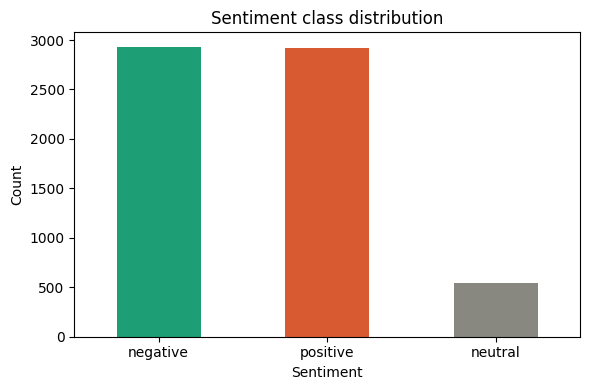

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df_balanced['sentiment'].value_counts()
colors = ['#1D9E75','#D85A30','#888780']
plt.figure(figsize=(6,4))
counts.plot(kind='bar', color=colors, edgecolor='none')
plt.title('Sentiment class distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

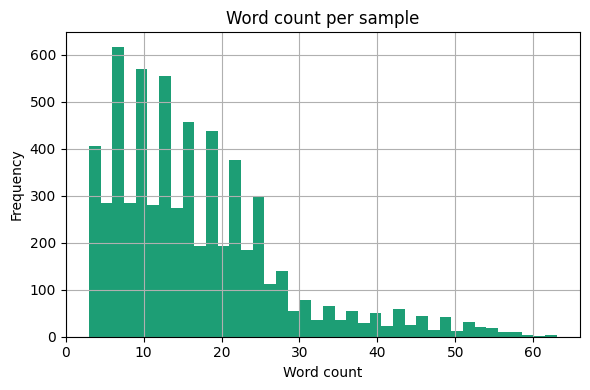

count    6394.000000
mean       16.640288
std        10.873565
min         3.000000
25%         9.000000
50%        14.000000
75%        22.000000
max        63.000000
Name: word_count, dtype: float64


In [31]:
df_combined['word_count'] = df_balanced['text_clean'].str.split().str.len()
plt.figure(figsize=(6,4))
df_combined['word_count'].hist(bins=40, color='#1D9E75', edgecolor='none')
plt.title('Word count per sample')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('token_lengths.png', dpi=150)
plt.show()
print(df_combined['word_count'].describe())

In [33]:
from sklearn.model_selection import train_test_split

label_encode = {'negative': 0, 'neutral': 1, 'positive': 2}
df_balanced['label'] = df_balanced['sentiment'].map(label_encode)

df_final = df_balanced[['text_clean', 'label', 'sentiment']].copy()
df_final = df_final.rename(columns={'text_clean': 'text'})

# 70% train / 15% val / 15% test — stratified to preserve class ratios
train, temp = train_test_split(df_final, test_size=0.30,random_state=42, stratify=df_final['label'])

val, test = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp['label'])

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print("\nTrain distribution:")
print(train['sentiment'].value_counts())

Train: 4475 | Val: 959 | Test: 960

Train distribution:
sentiment
negative    2051
positive    2042
neutral      382
Name: count, dtype: int64


In [34]:
train.to_csv("data_train.csv", index=False)
val.to_csv("data_val.csv",   index=False)
test.to_csv("data_test.csv", index=False)
df_final.to_csv("data_full.csv", index=False)

print("Files saved:")
print(f"  data_train.csv — {len(train)} rows")
print(f"  data_val.csv   — {len(val)} rows")
print(f"  data_test.csv  — {len(test)} rows")
print(f"  data_full.csv  — {len(df_final)} rows")

Files saved:
  data_train.csv — 4475 rows
  data_val.csv   — 959 rows
  data_test.csv  — 960 rows
  data_full.csv  — 6394 rows


In [35]:
!git config --global user.email "christianay57@example.com"
!git config --global user.name "ODUNAYOMIDE-YAKUBU"


In [36]:
!git clone https://github.com/ODUNAYOMIDE-YAKUBU/sentiment_chatbot.git

Cloning into 'sentiment_chatbot'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 19 (delta 1), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 4.68 KiB | 959.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
!cp /content/data_train.csv /content/your-repo/data/processed/
